In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)

TensorFlow: 2.21.0
NumPy: 2.3.3


In [2]:
# Dataset configuration
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

TRAIN_DIR = "../data/train"
TEST_DIR = "../data/test"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=42
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("Class names:", train_dataset.class_names)
print("Training batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Testing batches:", tf.data.experimental.cardinality(test_dataset).numpy())

Found 6633 files belonging to 2 classes.
Found 715 files belonging to 2 classes.
Class names: ['def_front', 'ok_front']
Training batches: 208
Testing batches: 23


In [3]:
# Split training data into training and validation sets
VALIDATION_SPLIT = 0.20

full_train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=42,
    validation_split=VALIDATION_SPLIT,
    subset="both"
)

train_dataset, validation_dataset = full_train_dataset

print("Training batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:", tf.data.experimental.cardinality(validation_dataset).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_dataset).numpy())

Found 6633 files belonging to 2 classes.
Using 5307 files for training.
Using 1326 files for validation.
Training batches: 166
Validation batches: 42
Test batches: 23


In [4]:
# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
], name="data_augmentation")

# Normalization
normalization_layer = layers.Rescaling(1.0 / 255)

print("Data augmentation and normalization layers created.")


Data augmentation and normalization layers created.


In [5]:
# Build the CNN model
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Data augmentation and normalization
    data_augmentation,
    normalization_layer,

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # Feature aggregation
    layers.GlobalAveragePooling2D(),

    # Regularization
    layers.Dropout(0.40),

    # Dense layer
    layers.Dense(64, activation="relu"),

    # Binary classification output
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Compile the CNN model
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


In [8]:
# Training callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2
    )
]

print("Training callbacks created successfully.")

Training callbacks created successfully.


In [9]:
# Train the CNN model
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25


c:\Users\patan\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


166/166 ━━━━━━━━━━━━━━━━━━━━ 96s 565ms/step - accuracy: 0.5685 - loss: 0.6873 - precision: 0.4000 - recall: 8.7374e-04 - val_accuracy: 0.5581 - val_loss: 0.6876 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 99s 595ms/step - accuracy: 0.5687 - loss: 0.6824 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.5581 - val_loss: 0.6828 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 97s 586ms/step - accuracy: 0.5736 - loss: 0.6778 - precision: 0.7708 - recall: 0.0162 - val_accuracy: 0.5581 - val_loss: 0.6675 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 98s 590ms/step - accuracy: 0.6277 - loss: 0.6463 - precision: 0.6148 - recall: 0.3661 - val_accuracy: 0.6357 - val_loss: 0.6283 - val_precision: 0.7943 - val_recall: 0.2372 - learning_rate: 0.0010
Epoch 5/25
166/166 ━━━━━━━━

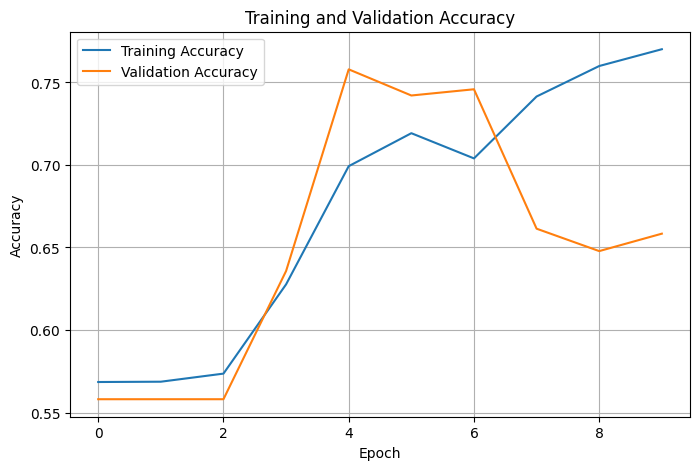

In [10]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.savefig("../reports/accuracy_graph.png", dpi=300, bbox_inches="tight")
plt.show()

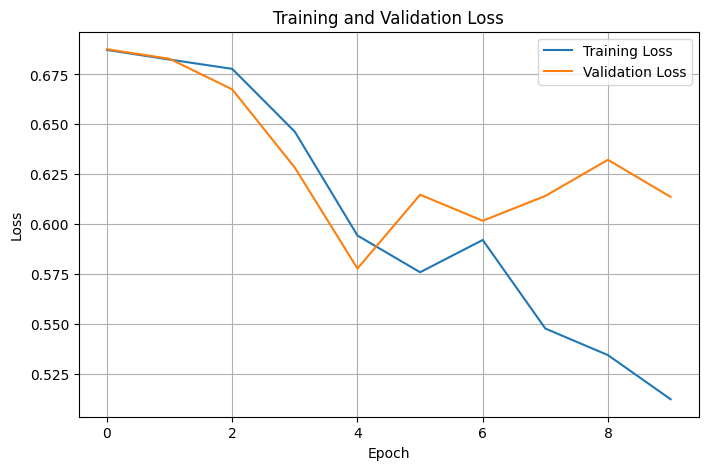

In [11]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.savefig("../reports/loss_graph.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
# Evaluate the trained model on the test dataset

test_results = model.evaluate(test_dataset, verbose=1)

print("\nTest Results:")
for name, value in zip(model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.7776 - loss: 0.5348 - precision: 0.8456 - recall: 0.4809

Test Results:
loss: 0.5348
compile_metrics: 0.7776


In [13]:
# Display test metrics clearly

test_loss = test_results[0]
test_accuracy = test_results[1]
test_precision = test_results[2]
test_recall = test_results[3]

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall   : {test_recall:.4f}")

Test Accuracy : 0.7776
Test Precision: 0.8456
Test Recall   : 0.4809


In [14]:
# Generate predictions on the test dataset

probabilities = model.predict(test_dataset)

predictions = (
    probabilities.flatten() >= 0.5
).astype(int)

print("Total predictions:", len(predictions))

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step
Total predictions: 715


In [15]:
# Get actual labels from the test dataset

actual_labels = np.concatenate([
    labels.numpy().flatten()
    for images, labels in test_dataset
])

print("Total actual labels:", len(actual_labels))

Total actual labels: 715


Confusion Matrix:
[[430  23]
 [136 126]]


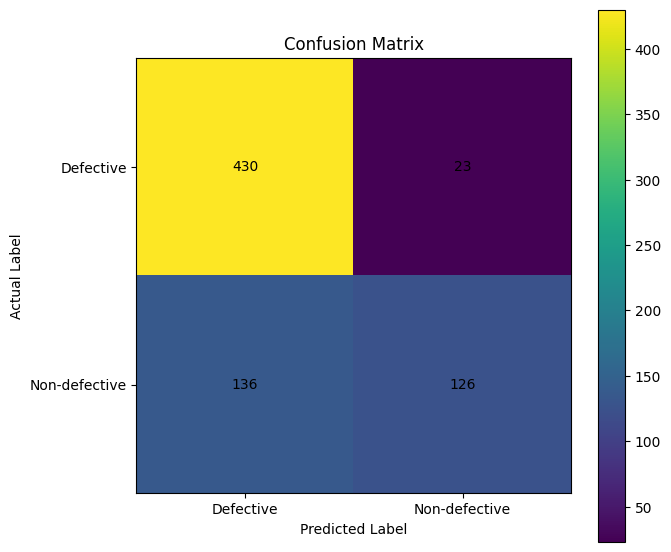

In [16]:
# Create and display the confusion matrix

cm = confusion_matrix(actual_labels, predictions)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 6))

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Defective", "Non-defective"])
plt.yticks([0, 1], ["Defective", "Non-defective"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.colorbar()
plt.tight_layout()

plt.savefig(
    "../reports/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Classification report
print("Classification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Defective", "Non-defective"]
    )
)

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\nModel Performance:")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Classification Report:


NameError: name 'y_true' is not defined

In [18]:
import pandas as pd
import os

os.makedirs("../reports", exist_ok=True)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [accuracy, precision, recall, f1]
})

metrics_df.to_csv("../reports/model_metrics.csv", index=False)

print("Saved: ../reports/model_metrics.csv")

NameError: name 'accuracy' is not defined

In [20]:
import numpy as np
import pandas as pd
import os
from sklearn.metrics import classification_report

# Confusion matrix values from the model evaluation
cm = np.array([
    [430, 23],
    [136, 126]
])

# Recreate true and predicted labels from the confusion matrix
y_true = np.array(
    [0] * 430 +
    [1] * 23 +
    [0] * 136 +
    [1] * 126
)

y_pred = np.array(
    [0] * 430 +
    [0] * 23 +
    [1] * 136 +
    [1] * 126
)

# Classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=["Defective", "Non-defective"]
)

print("Classification Report:")
print(report)

# Save classification report
os.makedirs("../reports", exist_ok=True)

with open("../reports/classification_report.txt", "w") as f:
    f.write("Casting Defect Detection - Classification Report\n")
    f.write("=" * 55 + "\n\n")
    f.write(report)

print("Saved: ../reports/classification_report.txt")

Classification Report:
               precision    recall  f1-score   support

    Defective       0.95      0.76      0.84       566
Non-defective       0.48      0.85      0.61       149

     accuracy                           0.78       715
    macro avg       0.72      0.80      0.73       715
 weighted avg       0.85      0.78      0.80       715

Saved: ../reports/classification_report.txt


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label=0)
recall = recall_score(y_true, y_pred, pos_label=0)
f1 = f1_score(y_true, y_pred, pos_label=0)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [accuracy, precision, recall, f1]
})

metrics_df.to_csv("../reports/model_metrics.csv", index=False)

print("Model Metrics:")
print(metrics_df)
print("\nSaved: ../reports/model_metrics.csv")

Model Metrics:
      Metric     Score
0   Accuracy  0.777622
1  Precision  0.949227
2     Recall  0.759717
3   F1 Score  0.843965

Saved: ../reports/model_metrics.csv


In [22]:
import os

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the trained model
model_path = "../models/casting_defect_cnn.keras"
model.save(model_path)

print("Model saved successfully!")
print("Path:", model_path)

Model saved successfully!
Path: ../models/casting_defect_cnn.keras


In [23]:
import os

print("Model exists:", os.path.exists("../models/casting_defect_cnn.keras"))

if os.path.exists("../models/casting_defect_cnn.keras"):
    print("Model size:",
          round(os.path.getsize("../models/casting_defect_cnn.keras") / (1024 * 1024), 2),
          "MB")

Model exists: True
Model size: 1.22 MB


In [24]:
import os

print("Reports folder:")
for file in sorted(os.listdir("../reports")):
    print(" -", file)

print("\nModels folder:")
for file in sorted(os.listdir("../models")):
    print(" -", file)

Reports folder:
 - accuracy_graph.png
 - classification_report.txt
 - confusion_matrix.png
 - loss_graph.png
 - model_metrics.csv

Models folder:
 - casting_defect_cnn.keras


In [25]:
import os

print("========== TASK 14 FILE CHECK ==========")

required_files = [
    "../models/casting_defect_cnn.keras",
    "../reports/model_metrics.csv",
    "../reports/classification_report.txt",
]

for file in required_files:
    print(f"{file} ->", "FOUND ✅" if os.path.exists(file) else "MISSING ❌")

print("\n========== REPORTS ==========")
if os.path.exists("../reports"):
    for f in sorted(os.listdir("../reports")):
        print("✓", f)

print("\n========== MODELS ==========")
if os.path.exists("../models"):
    for f in sorted(os.listdir("../models")):
        print("✓", f)

========== TASK 14 FILE CHECK ==========
../models/casting_defect_cnn.keras -> FOUND ✅
../reports/model_metrics.csv -> FOUND ✅
../reports/classification_report.txt -> FOUND ✅

========== REPORTS ==========
✓ accuracy_graph.png
✓ classification_report.txt
✓ confusion_matrix.png
✓ loss_graph.png
✓ model_metrics.csv

========== MODELS ==========
✓ casting_defect_cnn.keras
